# Intuition: Word2Vec (Predictive Embeddings)

Unlike **TF-IDF** (which counts words) or **GloVe** (which uses a global co-occurrence matrix), **Word2Vec** is a **predictive model**.

It trains a shallow Neural Network to predict a word given its neighbors (Context).

### The Two Architectures:
1.  **CBOW (Continuous Bag of Words):** The model looks at the **Context** (surrounding words) and tries to predict the **Center Word**.
    * *Input:* "The", "cat", "on", "mat" $\rightarrow$ *Prediction:* "sat"

2.  **Skip-gram:** The model looks at the **Center Word** and tries to predict the **Context** (surrounding words).
    * *Input:* "sat" $\rightarrow$ *Prediction:* "The", "cat", "on", "mat"

In [ ]:
from gensim.models import Word2Vec
import numpy as np
import logging

# Optional: Setup logging to see the training progress in the output
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [2]:
# We create a tiny dataset of sentences to train our model from scratch.
# In a real scenario, this would be millions of tweets or reviews.

sentences = [
    ['I', 'love', 'machine', 'learning', 'and', 'deep', 'learning'],
    ['machine', 'learning', 'is', 'amazing', 'and', 'fun'],
    ['I', 'love', 'coding', 'in', 'python'],
    ['python', 'is', 'a', 'great', 'language', 'for', 'data', 'science'],
    ['natural', 'language', 'processing', 'uses', 'word', 'embeddings'],
    ['word', 'embeddings', 'represent', 'text', 'as', 'numbers'],
    ['king', 'is', 'to', 'man', 'as', 'queen', 'is', 'to', 'woman'] # Trying to sneak in a relationship!
]

print(f"Training on {len(sentences)} sentences.")

Training on 7 sentences.


In [ ]:
# Train a Word2Vec model on our tiny corpus
# vector_size: Dimension of the vector (e.g., 10 dimensions for this simple test)
# window: How many neighbors to look at (2 words to the left, 2 to the right)
# min_count: Ignore words that appear less than 1 time
# workers=4: Use 4 CPU threads to train in parallel (faster for large data)
# sg: 1 for Skip-gram (better for small data), 0 for CBOW

model = Word2Vec(sentences, vector_size=10, window=2, min_count=1, workers=4, sg=1)

print("✅ Model training complete.")

2026-01-15 15:28:05,983 : INFO : collecting all words and their counts
2026-01-15 15:28:05,983 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-01-15 15:28:05,984 : INFO : collected 32 word types from a corpus of 47 raw words and 7 sentences
2026-01-15 15:28:05,984 : INFO : Creating a fresh vocabulary
2026-01-15 15:28:05,984 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 32 unique words (100.00% of original 32, drops 0)', 'datetime': '2026-01-15T15:28:05.984415', 'gensim': '4.3.3', 'python': '3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}
2026-01-15 15:28:05,985 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 47 word corpus (100.00% of original 47, drops 0)', 'datetime': '2026-01-15T15:28:05.985920', 'gensim': '4.3.3', 'python': '3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]', 'platform': 'Windows-10-1

✅ Model training complete.


In [5]:
# View the dictionary the model learned
# Note how it assigns a random-looking vector to every unique word it saw.

vocab = model.wv.index_to_key
print(f"Vocabulary Size: {len(vocab)}")
print(f"First 10 words: {vocab[:10]}")

Vocabulary Size: 32
First 10 words: ['is', 'learning', 'I', 'and', 'python', 'word', 'embeddings', 'as', 'machine', 'to']


In [6]:
# Let's see what the vector for 'python' looks like.
# These 10 numbers are the "coordinates" of the word 'python' in the 10-dimensional space.

word = 'python'
vector = model.wv[word]

print(f"Vector for '{word}':\n{vector}")
print(f"\nShape: {vector.shape}")

Vector for 'python':
[-0.09606595  0.05006402 -0.08751778 -0.04385497 -0.00036486 -0.0030058
 -0.0765523   0.0962347   0.04982646  0.09234971]

Shape: (10,)


In [7]:
# The magic of Word2Vec: finding words that appear in similar contexts.
# (Note: Since our dataset is tiny, these results won't be perfect, but they show the mechanics).

target_word = 'learning'

# Find the top 3 most similar words to 'learning'
similar_words = model.wv.most_similar(target_word, topn=3)

print(f"Words most similar to '{target_word}':")
for word, score in similar_words:
    print(f"  - {word} (Similarity Score: {score:.4f})")

Words most similar to 'learning':
  - is (Similarity Score: 0.5428)
  - natural (Similarity Score: 0.4119)
  - uses (Similarity Score: 0.4115)


## Key Parameters Explained

1.  **`vector_size`**: The number of "sliders" on the sound equalizer.
    * Small datasets (like this) use 10-50.
    * Huge datasets (Google News) use 300.
2.  **`window`**: The "peripheral vision" of the model.
    * **Small Window (2):** Focuses on syntax and immediate neighbors (e.g., "good" is similar to "great").
    * **Large Window (5+):** Focuses on the general topic (e.g., "Einstein" is similar to "Physics").
3.  **`sg` (Skip-gram vs CBOW)**:
    * **Skip-gram (`sg=1`)**: Generally learns better vectors for rare words.
    * **CBOW (`sg=0`)**: Faster to train.
4.  **`workers`**: This controls the **Training Speed**.
    * It tells the model how many CPU threads to use at the same time (Parallel Processing).
    * **For small datasets:** It doesn't matter (1 worker is fast enough).
    * **For huge datasets:** Set this to `Number of CPU Cores - 1` to train significantly faster.    

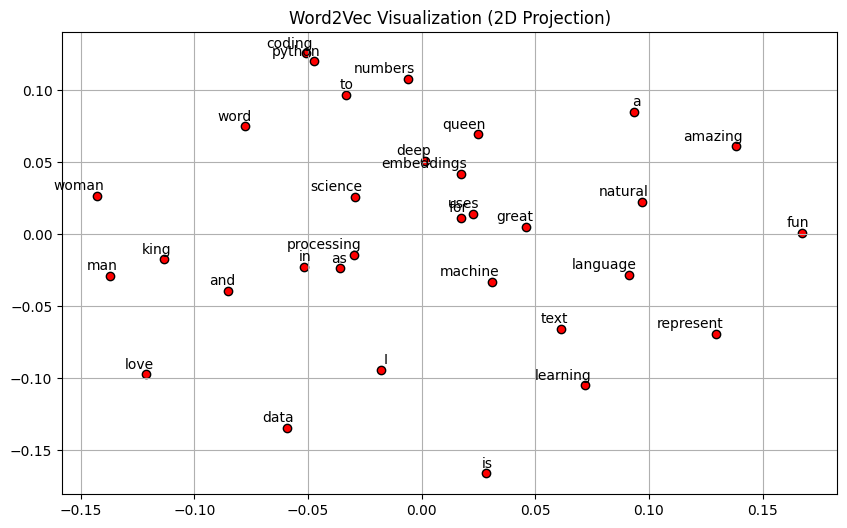

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Get all the word vectors from the model
words = list(model.wv.index_to_key)
vectors = model.wv[words]

# 2. Use PCA to reduce vectors from 10 dimensions to 2 dimensions
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# 3. Plot the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='red', edgecolors='k')

# 4. Add labels to each point so we know which word is which
for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2), 
                 textcoords='offset points', ha='right', va='bottom')

plt.title('Word2Vec Visualization (2D Projection)')
plt.grid(True)
plt.show()

### Visualizing the "End Result"

Since we cannot see in 10 dimensions, we used **PCA** to flatten the data onto your screen (2 dimensions).

**What to look for:**
* **Distance:** Words that are close together on this plot have similar meanings (or appear in similar contexts).
* **Clusters:** You might see "machine", "learning", and "deep" grouped together, or "king", "queen", "man", "woman" forming a loose shape.

*(Note: Since we only trained on 7 tiny sentences, the clusters won't be perfect! In a real model trained on Wikipedia, these relationships would be incredibly precise.)*